# 📊 DỰ ÁN: DỰ ĐOÁN ÙN TẮC GIAO THÔNG (TRAFFIC CONGESTION PREDICTION)
---

## 1. Giới thiệu bài toán & Đọc dữ liệu (Data Loading)
> **Mục tiêu:** Khám phá tập dữ liệu di chuyển của Taxi (`yellow_tripdata_2019-01 copy.csv`) và chuẩn bị nền tảng dữ liệu cho các bước xử lý tiếp theo.

* **Bài toán:** Dự đoán mức độ ùn tắc giao thông dựa trên các thông tin chuyến đi (thời gian, địa điểm đón/trả, khoảng cách...).
* **Dữ liệu đầu vào:** Tệp dữ liệu thô chứa lịch trình di chuyển của xe taxi màu vàng tại New York.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế lại giao diện đồ thị cho chuẩn chỉnh và đẹp mắt hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Loading dataset...")
df = pd.read_csv("cleaned_taxi_data.csv", low_memory=False)
print("Original Shape:", df.shape)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

Loading dataset...
Original Shape: (91612, 26)


In [8]:
df = pd.read_csv("cleaned_taxi_data.csv")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,trip_duration,pickup_hour,pickup_dayofweek,is_weekend,is_rush_hour,trip_speed,congestion_level,congestion_label
0,1.0,2019-01-01 00:46:00,2019-01-01 00:53:00,1.0,1.5,1.0,N,151.0,239.0,1.0,...,9.95,NaN,7.0,0,1,0,0,12.857143,Medium,2
1,1.0,2019-01-01 00:59:00,2019-01-01 01:18:00,1.0,2.6,1.0,N,239.0,246.0,1.0,...,16.30,NaN,19.0,0,1,0,0,8.210526,High,0
2,1.0,2019-01-01 00:21:00,2019-01-01 00:28:00,1.0,1.3,1.0,N,163.0,229.0,1.0,...,9.05,NaN,7.0,0,1,0,0,11.142857,Medium,2
3,1.0,2019-01-01 00:32:00,2019-01-01 00:45:00,1.0,3.7,1.0,N,229.0,7.0,1.0,...,18.50,NaN,13.0,0,1,0,0,17.076923,Medium,2
4,1.0,2019-01-01 00:57:00,2019-01-01 01:09:00,2.0,2.1,1.0,N,141.0,234.0,1.0,...,13.00,NaN,12.0,0,1,0,0,10.500000,Medium,2


## 2. Làm sạch & Tiền xử lý dữ liệu (Data Cleaning & Preprocessing)
> **Mục tiêu:** Xử lý dữ liệu thô, loại bỏ nhiễu và chuẩn hóa dữ liệu đầu vào (Ánh xạ từ file `data cleaning/main.py`).

* Xử lý giá trị thiếu (Missing values) và dữ liệu bất thường (Outliers).
* Chuyển đổi kiểu dữ liệu thời gian (`datetime`) để trích xuất các tính năng mới (Giờ, Thứ trong tuần).
* **Kết quả đầu ra:** Lưu tệp dữ liệu sạch thành `cleaned_taxi_data.csv`.

In [13]:
# Chuyển đổi datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')

# Xóa các dòng lỗi thời gian
df = df.dropna(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
print("After datetime cleaning:", df.shape)

After datetime cleaning: (91612, 26)


In [9]:
df.info()

df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()

<class 'pandas.DataFrame'>
RangeIndex: 91612 entries, 0 to 91611
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               91612 non-null  float64
 1   tpep_pickup_datetime   91612 non-null  str    
 2   tpep_dropoff_datetime  91612 non-null  str    
 3   passenger_count        91612 non-null  float64
 4   trip_distance          91612 non-null  float64
 5   RatecodeID             91612 non-null  float64
 6   store_and_fwd_flag     91612 non-null  str    
 7   PULocationID           91612 non-null  float64
 8   DOLocationID           91612 non-null  float64
 9   payment_type           91612 non-null  float64
 10  fare_amount            91612 non-null  float64
 11  extra                  91612 non-null  float64
 12  mta_tax                91612 non-null  float64
 13  tip_amount             91612 non-null  float64
 14  tolls_amount           91612 non-null  float64
 15  improvement_s

## 2.1. Kỹ nghệ đặc trưng (Feature Engineering)
> **Mục tiêu:** Tạo thêm các thuộc tính (features) mới từ dữ liệu gốc nhằm tăng độ chính xác cho các mô hình dự đoán ùn tắc.

Dựa trên đặc thù của dữ liệu chuyến đi Taxi, chúng ta sẽ tập trung trích xuất các nhóm đặc trưng sau:

### 📅 Thuộc tính Thời gian (Temporal Features)
* `hour`: Giờ trong ngày (0-23) - Giúp mô hình nhận biết giờ cao điểm/thấp điểm.
* `day_of_week`: Thứ trong tuần (0-6) - Phân biệt ngày đi làm (Thứ 2 - Thứ 6) và ngày cuối tuần.
* `is_weekend`: Biến phân loại (0 hoặc 1) xác định xem ngày đó có phải cuối tuần hay không.

### 📍 Thuộc tính Không gian (Spatial Features)
* `trip_distance`: Khoảng cách di chuyển của chuyến đi.
* `pickup_zone` / `dropoff_zone`: Các vùng đón/trả khách trọng điểm có nguy cơ ùn tắc cao.

### 🚗 Biến mục tiêu (Target Variable Construction)
* Xây dựng cột toán học định nghĩa mức độ ùn tắc (`congestion_level`) dựa trên tỷ lệ giữa **khoảng cách** và **thời gian di chuyển** (vận tốc trung bình của chuyến đi).

In [15]:
# Trích xuất các thuộc tính thời gian
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

# Tính thời lượng (phút) và vận tốc (mph)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Lọc dữ liệu hợp lệ và loại bỏ nhiễu (Outliers)
df = df[(df['trip_duration'] > 0) & (df['trip_distance'] > 0)]
df['trip_speed'] = df['trip_distance'] / (df['trip_duration'] / 60)
df = df[(df['trip_speed'] > 0) & (df['trip_speed'] < 80)]

# Gán nhãn biến mục tiêu (Congestion Level)
def congestion_level(speed):
    if speed < 10: return "High"
    elif speed < 20: return "Medium"
    else: return "Low"

df['congestion_level'] = df['trip_speed'].apply(congestion_level)

print("After feature engineering:", df.shape)
print("\nCongestion Level Distribution:")
print(df['congestion_level'].value_counts())

After feature engineering: (91612, 27)

Congestion Level Distribution:
congestion_level
Medium    52944
High      21759
Low       16909
Name: count, dtype: int64


## 3. Trực quan hóa dữ liệu (Exploratory Data Analysis - EDA)
> **Mục tiêu:** Phân tích biểu đồ để tìm ra quy luật và mối quan hệ giữa các biến (Ánh xạ từ file `visualization/main.py`).

* Trực quan hóa phân phối của biến mục tiêu (Mức độ ùn tắc).
* Phân tích xu hướng ùn tắc theo các khung giờ cao điểm và các ngày trong tuần.

C:\Users\Admin\AppData\Local\Temp\ipykernel_7140\4265057535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='congestion_level', order=['Low', 'Medium', 'High'], palette='viridis')


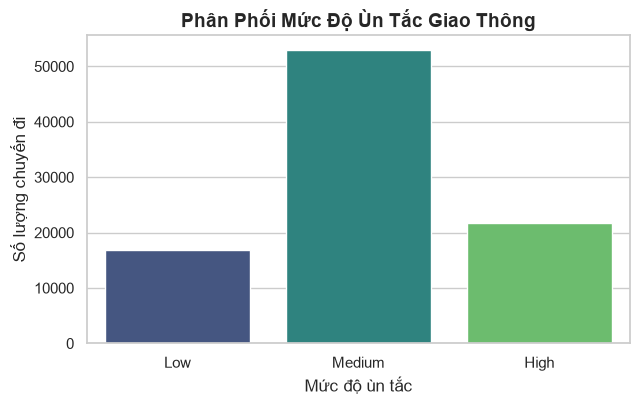

In [12]:
plt.figure(figsize=(7, 4))
# Sắp xếp thứ tự hiển thị trực quan từ Thấp đến Cao kèm palette màu cảnh báo
sns.countplot(data=df, x='congestion_level', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title("Phân Phối Mức Độ Ùn Tắc Giao Thông", fontsize=14, fontweight='bold')
plt.xlabel("Mức độ ùn tắc")
plt.ylabel("Số lượng chuyến đi")
plt.show()

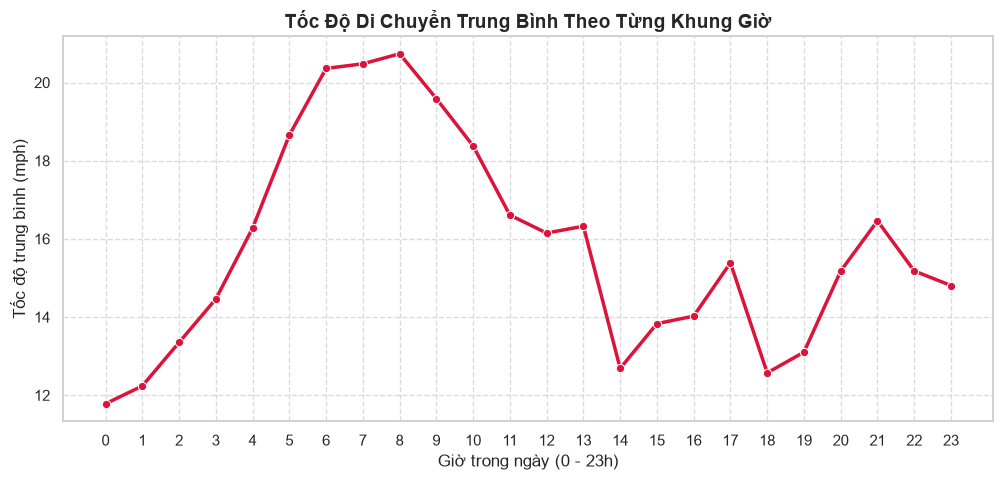

In [16]:
hourly = df.groupby('pickup_hour')['trip_speed'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o', color='crimson', linewidth=2.5)
plt.title("Tốc Độ Di Chuyển Trung Bình Theo Từng Khung Giờ", fontsize=14, fontweight='bold')
plt.xlabel("Giờ trong ngày (0 - 23h)")
plt.ylabel("Tốc độ trung bình (mph)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7140\1168656359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily.index, y=daily.values, palette='Blues_r')


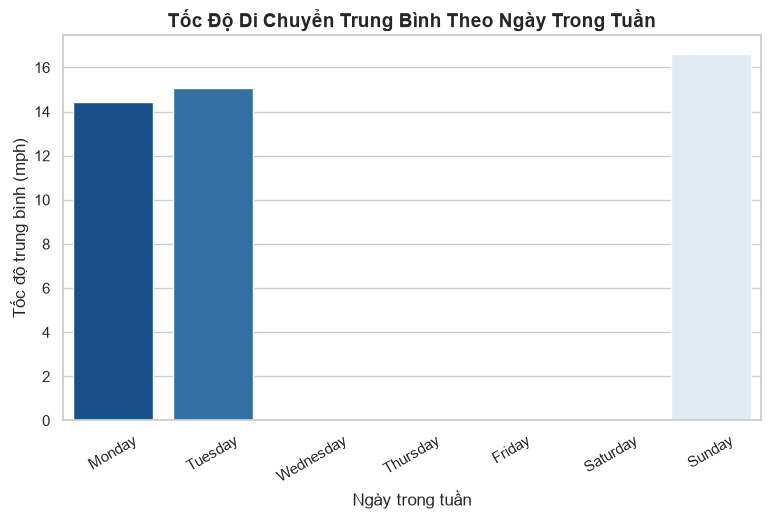

In [17]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('pickup_day')['trip_speed'].mean().reindex(day_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=daily.index, y=daily.values, palette='Blues_r')
plt.title("Tốc Độ Di Chuyển Trung Bình Theo Ngày Trong Tuần", fontsize=14, fontweight='bold')
plt.xlabel("Ngày trong tuần")
plt.ylabel("Tốc độ trung bình (mph)")
plt.xticks(rotation=30)
plt.show()

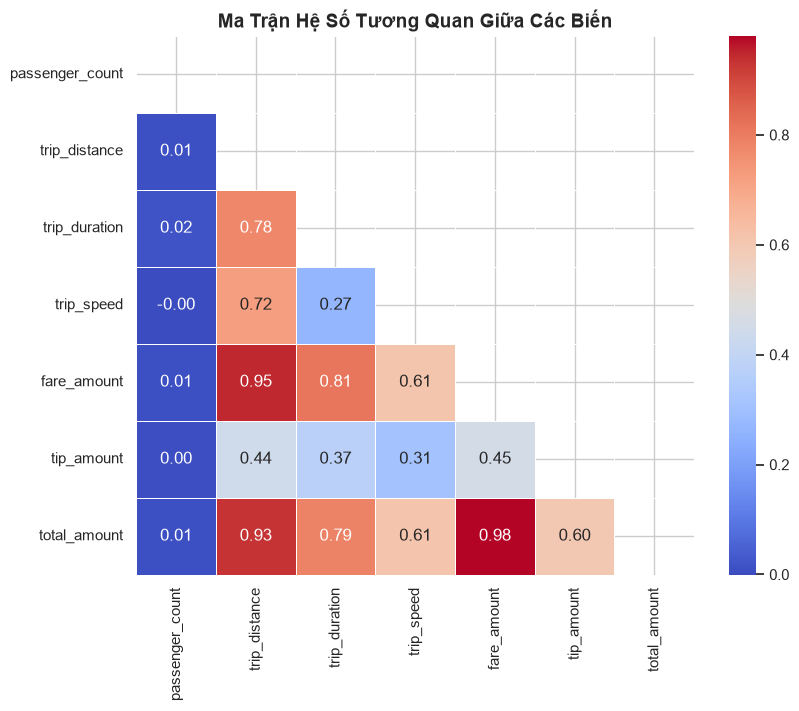

In [18]:
features = ['passenger_count', 'trip_distance', 'trip_duration', 'trip_speed', 'fare_amount', 'tip_amount', 'total_amount']
corr = df[features].corr()

plt.figure(figsize=(9, 7))
# Dùng mask để ẩn đi một nửa ma trận đối xứng giúp biểu đồ thoáng hơn (tùy chọn)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Ma Trận Hệ Số Tương Quan Giữa Các Biến", fontsize=14, fontweight='bold')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7140\661275357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pickup.index.astype(str), y=top_pickup.values, palette='Reds_r')


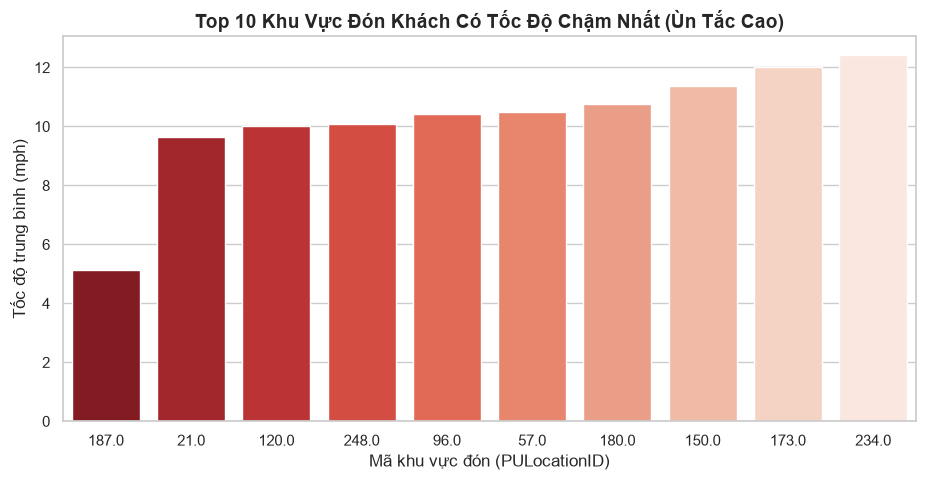


Final Dataset Shape: (91612, 27)
Analysis Completed Successfully!


In [19]:
top_pickup = df.groupby('PULocationID')['trip_speed'].mean().sort_values().head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_pickup.index.astype(str), y=top_pickup.values, palette='Reds_r')
plt.title("Top 10 Khu Vực Đón Khách Có Tốc Độ Chậm Nhất (Ùn Tắc Cao)", fontsize=14, fontweight='bold')
plt.xlabel("Mã khu vực đón (PULocationID)")
plt.ylabel("Tốc độ trung bình (mph)")
plt.show()

print("\nFinal Dataset Shape:", df.shape)
print("Analysis Completed Successfully!")

## 4. Huấn luyện các mô hình (Model Training)
> **Mục tiêu:** Xây dựng và huấn luyện nhiều thuật toán học máy khác nhau để tìm ra mô hình dự đoán tốt nhất (Tích hợp từ thư mục `model/`).

* **Bước 1:** Chia tập dữ liệu thành Train/Test.
* **Bước 2:** Huấn luyện lần lượt các mô hình:
    * Random Forest (`random_forest_congestion.py`)
    * Gradient Boosting (`gradient_boosting_congestion.py`)
    * HistGradient Boosting (`HistGradientBoosting.py`)
    * MLP / XGBoost (`mlp_model.py` & `xgboost_model.py`)

## 5. Đánh giá & So sánh mô hình (Model Evaluation & Comparison)
> **Mục tiêu:** Đánh giá hiệu năng và lựa chọn mô hình tối ưu nhất để đưa vào triển khai thực tế.

* Phân tích chi tiết mô hình tối ưu thông qua **Classification Report** (Precision, Recall, F1-score) và **Confusion Matrix** (lấy từ thư mục `results_HistGradientBoosting/`).
* So sánh trực quan hóa kết quả giữa tất cả các mô hình dựa trên file `compare_models.py`.

## 6. Lưu trữ và Tích hợp hệ thống (Database & API)
> **Mục tiêu:** Đóng gói mô hình và kết nối hệ thống phục vụ ứng dụng thực tế.

* **Database (`traffic_congestion.db`):** Lưu trữ lịch sử dự đoán và dữ liệu sạch bằng SQLite.
* **API Service (`api/api.py`):** Triển khai mô hình dưới dạng REST API (FastAPI/Flask) để phục vụ dự đoán thời gian thực (Real-time Prediction).